In [1]:
#name: Susmita kunwar
#student id: 2461844
#worksheet 7


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error


Part-1: Regression Task

In [6]:
from sklearn.datasets import load_diabetes

# Load a regression dataset (Diabetes)
X, y = load_diabetes(return_X_y=True)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


TASK-2 : REGRESSION


In [10]:
#STEP-1
#Baseline Model (No Regularization) Build a Linear Regression model without any regularization.
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

print("Baseline coefficients:", baseline_model.coef_)
print("Baseline intercept:", baseline_model.intercept_)


Baseline coefficients: [  37.90402135 -241.96436231  542.42875852  347.70384391 -931.48884588
  518.06227698  163.41998299  275.31790158  736.1988589    48.67065743]
Baseline intercept: 151.34560453985995


In [8]:
y_train_pred_baseline = baseline_model.predict(X_train)
y_test_pred_baseline = baseline_model.predict(X_test)

mse_train_baseline = mean_squared_error(y_train, y_train_pred_baseline)
mse_test_baseline = mean_squared_error(y_test, y_test_pred_baseline)

print("Baseline MSE (train):", mse_train_baseline)
print("Baseline MSE (test):", mse_test_baseline)


Baseline MSE (train): 2868.549702835577
Baseline MSE (test): 2900.193628493482


In [11]:
#STEP-2
#Step 2: Hyperparameter Tuning Use GridSearchCV or RandomizedSearchCV to tune hyperparameters for Ridge and Lasso regression models.
alpha_values = [0.001, 0.01, 0.1, 1, 10, 100]

ridge = Ridge()
ridge_param_grid = {"alpha": alpha_values}

ridge_grid = GridSearchCV(
    ridge,
    ridge_param_grid,
    cv=5,
    scoring="neg_mean_squared_error"
)
ridge_grid.fit(X_train, y_train)

print("Best Ridge alpha:", ridge_grid.best_params_["alpha"])
print("Best Ridge CV score (neg MSE):", ridge_grid.best_score_)


Best Ridge alpha: 0.1
Best Ridge CV score (neg MSE): -3125.190774634348


In [12]:
lasso = Lasso(max_iter=10000)
lasso_param_grid = {"alpha": alpha_values}

lasso_grid = GridSearchCV(
    lasso,
    lasso_param_grid,
    cv=5,
    scoring="neg_mean_squared_error"
)
lasso_grid.fit(X_train, y_train)

print("Best Lasso alpha:", lasso_grid.best_params_["alpha"])
print("Best Lasso CV score (neg MSE):", lasso_grid.best_score_)

Best Lasso alpha: 0.1
Best Lasso CV score (neg MSE): -3128.8885394876356


In [13]:
best_ridge = ridge_grid.best_estimator_
best_lasso = lasso_grid.best_estimator_

y_test_pred_ridge = best_ridge.predict(X_test)
y_test_pred_lasso = best_lasso.predict(X_test)

mse_test_ridge = mean_squared_error(y_test, y_test_pred_ridge)
mse_test_lasso = mean_squared_error(y_test, y_test_pred_lasso)

print("Best Ridge MSE (test):", mse_test_ridge)
print("Best Lasso MSE (test):", mse_test_lasso)

Best Ridge MSE (test): 2856.4868876706537
Best Lasso MSE (test): 2798.193485169719


In [14]:
#Step 3: Regularization Experiments (L1 vs L2) Train L1 (Lasso) and L2 (Ridge) regression models using the optimal hyperparameters.
ridge_final = best_ridge
lasso_final = best_lasso

ridge_coefs = ridge_final.coef_
lasso_coefs = lasso_final.coef_

print("Ridge coefficients:", ridge_coefs)
print("Lasso coefficients:", lasso_coefs)

Ridge coefficients: [  42.85566976 -205.49431899  505.08903304  317.0932049  -108.50026183
  -86.23673333 -190.36318008  151.70708637  392.28931896   79.9081772 ]
Lasso coefficients: [   0.         -152.66477923  552.69777529  303.36515791  -81.36500664
   -0.         -229.25577639    0.          447.91952518   29.64261704]


In [15]:
y_train_pred_ridge = ridge_final.predict(X_train)
y_train_pred_lasso = lasso_final.predict(X_train)

mse_train_ridge = mean_squared_error(y_train, y_train_pred_ridge)
mse_train_lasso = mean_squared_error(y_train, y_train_pred_lasso)
mse_test_ridge = mean_squared_error(y_test, y_test_pred_ridge)
mse_test_lasso = mean_squared_error(y_test, y_test_pred_lasso)

print("Ridge MSE (train):", mse_train_ridge)
print("Ridge MSE (test):", mse_test_ridge)
print("Lasso MSE (train):", mse_train_lasso)
print("Lasso MSE (test):", mse_test_lasso)


Ridge MSE (train): 2912.983541587901
Ridge MSE (test): 2856.4868876706537
Lasso MSE (train): 2935.25823259759
Lasso MSE (test): 2798.193485169719


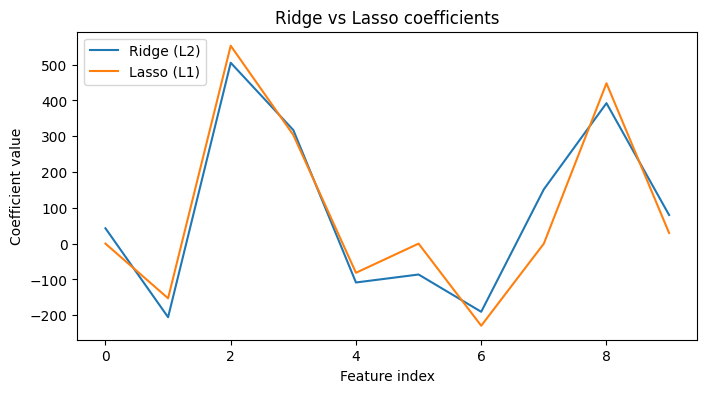

In [16]:
plt.figure(figsize=(8,4))
plt.plot(ridge_coefs, label="Ridge (L2)")
plt.plot(lasso_coefs, label="Lasso (L1)")
plt.xlabel("Feature index")
plt.ylabel("Coefficient value")
plt.title("Ridge vs Lasso coefficients")
plt.legend()
plt.show()


Part-2: Classification Task (Breast Cancer)

In [17]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV, train_test_split


In [18]:
X_cls, y_cls = load_breast_cancer(return_X_y=True)

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)

X_train_cls.shape, X_test_cls.shape


((455, 30), (114, 30))

In [19]:
#Step-1:Baseline logistic regression
baseline_log_reg = LogisticRegression(max_iter=10000)  # default L2
baseline_log_reg.fit(X_train_cls, y_train_cls)

print("Baseline coefficients shape:", baseline_log_reg.coef_.shape)
print("First 10 coefficients:", baseline_log_reg.coef_[0][:10])


Baseline coefficients shape: (1, 30)
First 10 coefficients: [ 1.0274368   0.22145051 -0.36213488  0.0254667  -0.15623532 -0.23771256
 -0.53255786 -0.28369224 -0.22668189 -0.03649446]


In [20]:
y_train_pred_baseline_cls = baseline_log_reg.predict(X_train_cls)
y_test_pred_baseline_cls = baseline_log_reg.predict(X_test_cls)

acc_train_baseline = accuracy_score(y_train_cls, y_train_pred_baseline_cls)
acc_test_baseline = accuracy_score(y_test_cls, y_test_pred_baseline_cls)

print("Baseline accuracy (train):", acc_train_baseline)
print("Baseline accuracy (test):", acc_test_baseline)


Baseline accuracy (train): 0.9582417582417583
Baseline accuracy (test): 0.956140350877193


In [21]:
log_reg = LogisticRegression(max_iter=10000, solver="liblinear")

param_grid_log = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"]
}

log_grid = GridSearchCV(
    log_reg,
    param_grid_log,
    cv=5,
    scoring="accuracy"
)
log_grid.fit(X_train_cls, y_train_cls)

print("Best hyperparameters:", log_grid.best_params_)
print("Best CV accuracy:", log_grid.best_score_)


Best hyperparameters: {'C': 100, 'penalty': 'l1'}
Best CV accuracy: 0.9670329670329672


In [22]:
#Step-2: Hyperparameter tuning (C and penalty)
log_reg = LogisticRegression(max_iter=10000, solver="liblinear")

param_grid_log = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"]
}

log_grid = GridSearchCV(
    log_reg,
    param_grid_log,
    cv=5,
    scoring="accuracy"
)
log_grid.fit(X_train_cls, y_train_cls)

print("Best hyperparameters:", log_grid.best_params_)
print("Best CV accuracy:", log_grid.best_score_)


Best hyperparameters: {'C': 100, 'penalty': 'l1'}
Best CV accuracy: 0.9670329670329672


In [23]:
best_log_model = log_grid.best_estimator_
y_test_pred_best = best_log_model.predict(X_test_cls)
acc_test_best = accuracy_score(y_test_cls, y_test_pred_best)

print("Best tuned model accuracy (test):", acc_test_best)


Best tuned model accuracy (test): 0.9824561403508771


In [24]:
#Step-3: L1 vs L2 logistic regression comparison
best_C = log_grid.best_params_["C"]

log_l1 = LogisticRegression(
    C=best_C,
    penalty="l1",
    solver="liblinear",
    max_iter=10000
)
log_l2 = LogisticRegression(
    C=best_C,
    penalty="l2",
    solver="liblinear",
    max_iter=10000
)

log_l1.fit(X_train_cls, y_train_cls)
log_l2.fit(X_train_cls, y_train_cls)

coefs_l1 = log_l1.coef_[0]
coefs_l2 = log_l2.coef_[0]

print("Number of zero coefficients (L1):", np.sum(coefs_l1 == 0))
print("Number of zero coefficients (L2):", np.sum(coefs_l2 == 0))


Number of zero coefficients (L1): 9
Number of zero coefficients (L2): 0


In [25]:
y_train_pred_l1 = log_l1.predict(X_train_cls)
y_test_pred_l1 = log_l1.predict(X_test_cls)

y_train_pred_l2 = log_l2.predict(X_train_cls)
y_test_pred_l2 = log_l2.predict(X_test_cls)

acc_train_l1 = accuracy_score(y_train_cls, y_train_pred_l1)
acc_test_l1 = accuracy_score(y_test_cls, y_test_pred_l1)

acc_train_l2 = accuracy_score(y_train_cls, y_train_pred_l2)
acc_test_l2 = accuracy_score(y_test_cls, y_test_pred_l2)

print("L1 accuracy (train):", acc_train_l1)
print("L1 accuracy (test):", acc_test_l1)
print("L2 accuracy (train):", acc_train_l2)
print("L2 accuracy (test):", acc_test_l2)


L1 accuracy (train): 0.989010989010989
L1 accuracy (test): 0.9824561403508771
L2 accuracy (train): 0.9692307692307692
L2 accuracy (test): 0.956140350877193


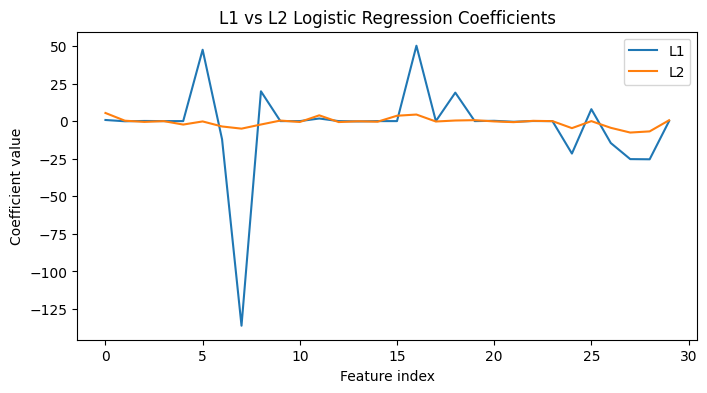

In [26]:
plt.figure(figsize=(8,4))
plt.plot(coefs_l1, label="L1")
plt.plot(coefs_l2, label="L2")
plt.xlabel("Feature index")
plt.ylabel("Coefficient value")
plt.title("L1 vs L2 Logistic Regression Coefficients")
plt.legend()
plt.show()
